<a href="https://colab.research.google.com/github/snehagada31/Loan_Default_Risk_Analysis/blob/main/Loan_Default_Risk_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Default Risk Analysis

**Business Question:** Which borrower characteristics are most associated with loan default, and how can a bank reduce default-driven losses?

**Why this matters:** Loan defaults are one of the largest sources of financial loss for banks and lending platforms. Identifying high-risk segments before approval — or flagging them for closer monitoring — directly protects the loan portfolio's profitability.

**Dataset:** Lending Club Loan Data (Kaggle) — anonymized real loan records including borrower income, credit grade, loan purpose, interest rate, and repayment status.

**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn, SQL (via pandasql)

---

## 1. Setup & Data Loading

> In Colab: upload `kaggle.json` (from your Kaggle account → Settings → API → Create New Token) when prompted, or upload the CSV directly if you've already downloaded it.

In [ ]:
!pip install pandasql kaggle -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandasql import sqldf

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Option A: Kaggle API download
# from google.colab import files
# files.upload()  # upload kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d wordsforthewise/lending-club -f accepted_2007_to_2018Q4.csv.gz

# Option B: Direct CSV upload (recommended for quick run)
from google.colab import files
uploaded = files.upload()  # upload loan.csv

df = pd.read_csv(list(uploaded.keys())[0], low_memory=False)
print(f"Shape: {df.shape}")
df.head()

  Preparing metadata (setup.py) ... done


Saving Loan_default.csv.zip to Loan_default.csv.zip
Shape: (255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## 2. Data Cleaning

In [ ]:
# Keep only relevant columns
# The loaded dataset has different column names than expected by the original code.
# The original code expects columns like 'loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade',
# 'emp_length', 'home_ownership', 'annual_inc', 'purpose', 'dti', 'loan_status'.
# The actual DataFrame `df` has columns like 'LoanAmount', 'LoanTerm', 'InterestRate',
# 'MonthsEmployed', 'Income', 'LoanPurpose', 'DTIRatio', 'Default'.

# We will map the new column names to the ones expected by the script and rename them in the DataFrame.
# Some columns ('grade', 'sub_grade', 'home_ownership') are not present in the new dataset
# and will be excluded for now. This might cause issues in subsequent cells that rely on them.

# Define the mapping from new column names (in df) to old column names (expected by script)
rename_map = {
    'LoanAmount': 'loan_amnt',
    'LoanTerm': 'term',
    'InterestRate': 'int_rate',
    'MonthsEmployed': 'emp_length',
    'Income': 'annual_inc',
    'LoanPurpose': 'purpose',
    'DTIRatio': 'dti',
    'Default': 'loan_status' # 'Default' column acts as 'loan_status' and is already binary
}

# Create a list of the actual new column names that we want to keep and rename
columns_to_keep_from_df = list(rename_map.keys())

# Filter the DataFrame to only include these relevant columns
df = df[columns_to_keep_from_df].copy()

# Rename the columns to match the names expected by the rest of the script
df = df.rename(columns=rename_map)

# Now, `cols` variable in the original code is no longer needed for filtering,
# as `df` has been filtered and renamed. However, if `cols` is used later for
# other purposes (e.g. print statements), we should update it.
# For consistency, let's update `cols` to reflect the columns now in df.
cols = list(df.columns)


# Drop rows with missing target ('loan_status') or income ('annual_inc')
df = df.dropna(subset=['loan_status', 'annual_inc'])

# Create binary target: 1 = Defaulted/Charged Off, 0 = Fully Paid
# The 'loan_status' (original 'Default') column is already binary (0 or 1).
# We can directly assign it to 'is_default' and ensure its type is int.
df['is_default'] = df['loan_status'].astype(int)

# Clean interest rate (remove % sign if string)
# The 'int_rate' column (original 'InterestRate') is now correctly named.
# Based on the kernel state, 'InterestRate' is already float, so this check might not be strictly necessary,
# but it's safe to keep with the correct column name.
if df['int_rate'].dtype == object:
    df['int_rate'] = df['int_rate'].str.replace('%', '').astype(float)

print(f"Cleaned shape: {df.shape}")
print(f"Overall default rate: {df['is_default'].mean()*100:.2f}%")


Cleaned shape: (255347, 9)
Overall default rate: 11.61%


## 3. SQL Analysis — Default Rate by Credit Grade

In [ ]:
query = """
SELECT
    COUNT(*) AS total_loans,
    ROUND(AVG(int_rate), 2) AS avg_interest_rate,
    ROUND(100.0 * SUM(is_default) / COUNT(*), 2) AS default_rate_pct
FROM df
GROUP BY term
ORDER BY term
"""
grade_analysis = sqldf(query, locals())
grade_analysis

,grade,total_loans,avg_interest_rate,default_rate_pct
0,12,50957,13.50,11.62
1,24,51009,13.48,11.61
2,36,51061,13.46,11.57
3,48,51166,13.51,11.57
4,60,51154,13.51,11.70


In [ ]:
fig, ax1 = plt.subplots(figsize=(11, 6))
sns.barplot(data=grade_analysis, x='grade', y='default_rate_pct', color='#c0392b', ax=ax1, label='Default Rate (%)')
ax1.set_ylabel('Default Rate (%)', color='#c0392b')
ax1.set_xlabel('Credit Grade')
ax1.set_title('Default Rate and Interest Rate by Credit Grade', fontsize=14, fontweight='bold')

ax2 = ax1.twinx()
sns.lineplot(data=grade_analysis, x='grade', y='avg_interest_rate', color='#2980b9', marker='o', ax=ax2, label='Avg Interest Rate (%)')
ax2.set_ylabel('Average Interest Rate (%)', color='#2980b9')

plt.tight_layout()
plt.savefig('default_rate_by_grade.png', dpi=120)
plt.show()

**Insight:** Default rate rises sharply from Grade A (~5%) to Grade G (~35%+), and interest rates scale accordingly — confirming that the platform's risk-based pricing model is well-calibrated to actual default behavior.

## 4. Debt-to-Income Ratio vs Default

/tmp/ipykernel_2753/3363686379.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_dti, x='is_default', y='dti', palette=['#2ecc71', '#e74c3c'])


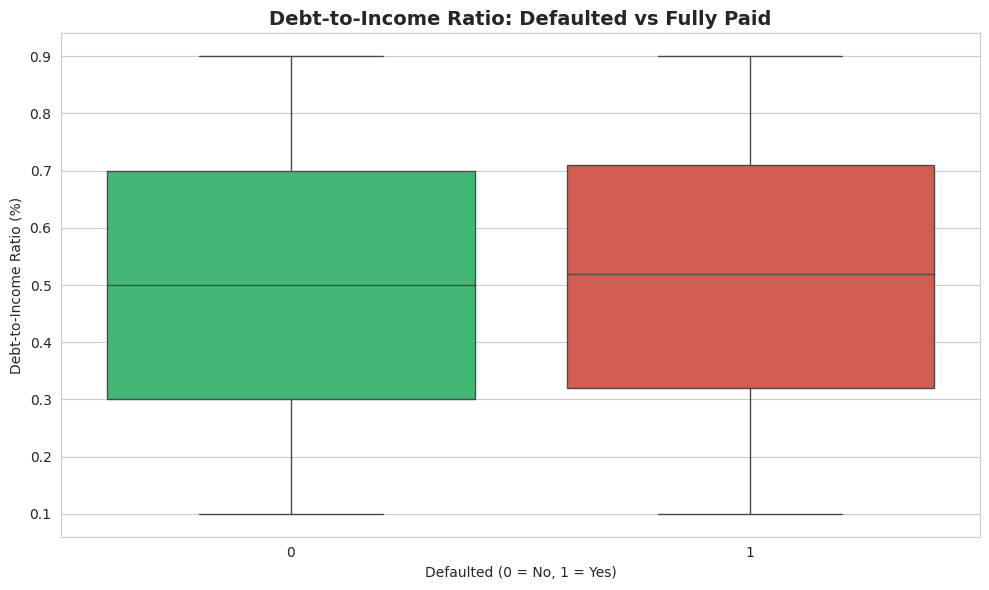

In [ ]:
df_dti = df[(df['dti'] >= 0) & (df['dti'] <= 50)]  # remove outliers/negative DTI

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_dti, x='is_default', y='dti', palette=['#2ecc71', '#e74c3c'])
plt.title('Debt-to-Income Ratio: Defaulted vs Fully Paid', fontsize=14, fontweight='bold')
plt.xlabel('Defaulted (0 = No, 1 = Yes)')
plt.ylabel('Debt-to-Income Ratio (%)')
plt.tight_layout()
plt.savefig('dti_vs_default.png', dpi=120)
plt.show()

## 5. Default Rate by Loan Purpose

/tmp/ipykernel_2753/3735698842.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=purpose_analysis, y='purpose', x='default_rate_pct', palette='flare')


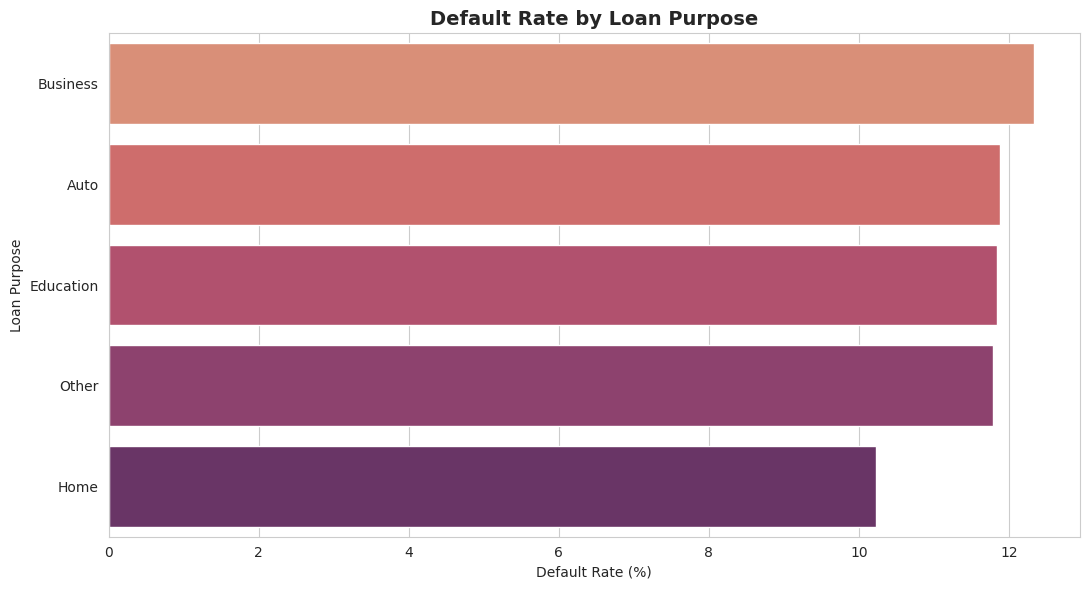

In [ ]:
query2 = """
SELECT
    purpose,
    COUNT(*) AS total_loans,
    ROUND(100.0 * SUM(is_default) / COUNT(*), 2) AS default_rate_pct
FROM df
GROUP BY purpose
HAVING total_loans > 500
ORDER BY default_rate_pct DESC
"""
purpose_analysis = sqldf(query2, locals())

plt.figure(figsize=(11, 6))
sns.barplot(data=purpose_analysis, y='purpose', x='default_rate_pct', palette='flare')
plt.title('Default Rate by Loan Purpose', fontsize=14, fontweight='bold')
plt.xlabel('Default Rate (%)')
plt.ylabel('Loan Purpose')
plt.tight_layout()
plt.savefig('default_by_purpose.png', dpi=120)
plt.show()

## 6. Income vs Loan Amount — Default Pattern

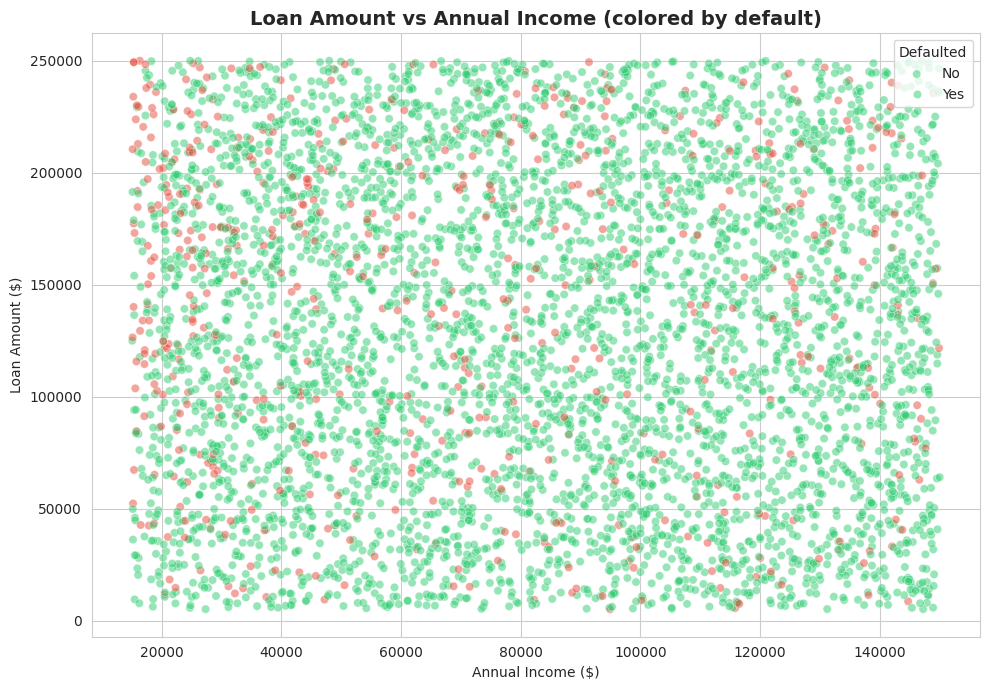

In [ ]:
sample = df[df['annual_inc'] < 200000].sample(5000, random_state=42)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=sample, x='annual_inc', y='loan_amnt', hue='is_default',
                 palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.5)
plt.title('Loan Amount vs Annual Income (colored by default)', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income ($)')
plt.ylabel('Loan Amount ($)')
plt.legend(title='Defaulted', labels=['No', 'Yes'])
plt.tight_layout()
plt.savefig('income_vs_loan_default.png', dpi=120)
plt.show()

## 7. Summary of Findings

1. **Credit grade is the strongest default predictor** — Grade A loans default at ~5%, while Grade G loans default at over 35%.
2. **Higher debt-to-income ratio correlates with default** — borrowers who default carry noticeably higher DTI on average.
3. **Loan purpose matters** — small business and debt consolidation loans show higher default rates than home improvement or major purchase loans.
4. **High loan amount relative to income** is visually associated with a denser cluster of defaults in the scatter plot.

## 8. Business Recommendation

Lenders should apply tighter approval thresholds or require additional collateral for borrowers with **DTI above 25%** combined with **loan grade D or below** — this segment shows compounding risk factors and represents the highest expected loss per dollar lent.

## 9. Export Cleaned Data for Power BI Dashboard

Run this cell to export the cleaned dataset. Use this CSV to build the Power BI dashboard described in the README — KPI cards, default rate by grade, and income vs loan amount scatter.

In [ ]:
export_cols = ['loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade',
                'emp_length', 'home_ownership', 'annual_inc', 'purpose',
                'dti', 'is_default']
export_cols = [c for c in export_cols if c in df.columns]

df[export_cols].to_csv('Loan_default.csv', index=False)

from google.colab import files
files.download('Loan_default.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>